In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2
%reload_ext autoreload
def housing_data_reader(filename='./data/housing_price.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['MEDV'],axis = 1)
    y =  data['MEDV']
    return X, y

def heart_disease_data_reader(filename='./data/diabetes_binary_health_indicators_BRFSS2015.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['Diabetes_binary', 'Education'],axis = 1)
    y =  data['Diabetes_binary']
    return X, y

def h1n1_data_reader(filename='./data/process_data.csv'):
    data = pd.read_csv(filename)
    X = data.drop(['h1n1_vaccine','respondent_id','seasonal_vaccine'],axis = 1)
    y =  data['h1n1_vaccine']
    return X, y

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define the characteristic function

In [28]:
from sklearn.model_selection import train_test_split
import lightgbm as lgb
from sklearn.metrics import r2_score
# define the characteristic function
def classification_kpi(G,S):
    """_summary_

    Args:
        G (nx.Graph): _description_
        S (list): list of nodes (list of columns)
    """
    cols = list(S)
    if len(cols) == 0:
        return 0
    else:
        X_train, X_test, y_train, y_test = train_test_split(X_vac_mst[cols], y_vac_mst, test_size=0.2, random_state=42)
        lgb_model = lgb.LGBMRegressor(learning_rate=0.2, verbosity=-1)

        lgb_model.fit(X_train,y_train)
        lgb_pred = lgb_model.predict(X_test)
        r2 = r2_score(y_test, lgb_pred)
        return r2

In [11]:
import seaborn as sns
import networkx as nx

# plot the networkx graph for W and W_new
def plot_graph(W, file_name=None):
    """_summary_

    Args:
        W (pd.DataFrame): weight matrix
    """
    G = nx.Graph(W)
    plt.figure(figsize=(5, 5))
    nx.draw_shell(G, with_labels=True)
    if file_name is not None:
        plt.savefig(file_name, format='eps', dpi=300)
    plt.show()

### Import shapG, some necessary libraries and explain the model

In [12]:
# import shapG and necessary libraries
import networkx as nx
import seaborn as sns
from sklearn.metrics import mutual_info_score
from sklearn.feature_selection import mutual_info_regression
from scipy.stats import pearsonr,kendalltau,spearmanr
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname('.'), '..')))
import shapG.shapley as shapley
import shapG.plot as shapGplot
from shapG.utils import corr_generator, create_minimal_edge_graph, matrix_generator, kl, kl_mi_matrix


In [13]:
from shapG.lasso import *
from shapG.mst import *
from shapG.mst_graph import *

v3 terminating at weight: 0.10006871034512797


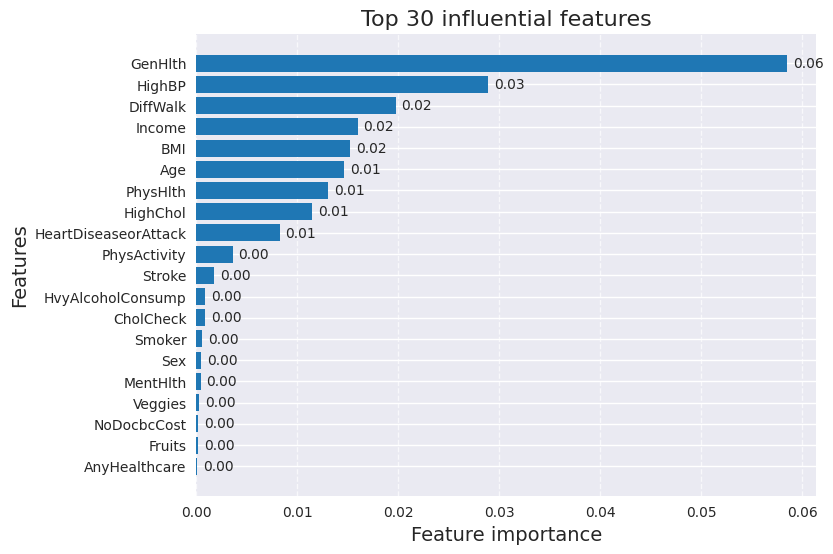

In [22]:
# explain the model
X_vac_org, y_vac_org = heart_disease_data_reader('./data/diabetes_binary_health_indicators_BRFSS2015.csv')
W_vac_org = matrix_generator(X_vac_org, pearsonr)
A_vac_org, W_new_vac_org = create_minimal_edge_graph(W_vac_org, reverse=True, version='v3', verbose=True)
G_vac_org = nx.Graph(A_vac_org)
shapley_value_vac_org = shapley.shapG(G_vac_org, m=3, f=classification_kpi, approximate_by_ratio=True)
fig_org, ax_org = shapGplot(shapley_value_vac_org, top_n=30, show_plot=False)
ax_org.set_xlabel("Feature importance", fontsize=14)
ax_org.set_ylabel("Features", fontsize=14)
ax_org.spines['top'].set_visible(False)
ax_org.spines['right'].set_visible(False)
ax_org.set_title('Top 30 influential features', fontsize=16)
plt.show()

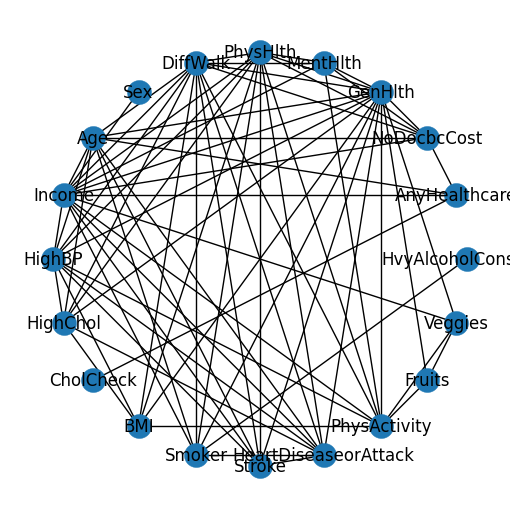

In [23]:
plot_graph(W_new_vac_org, file_name=None)

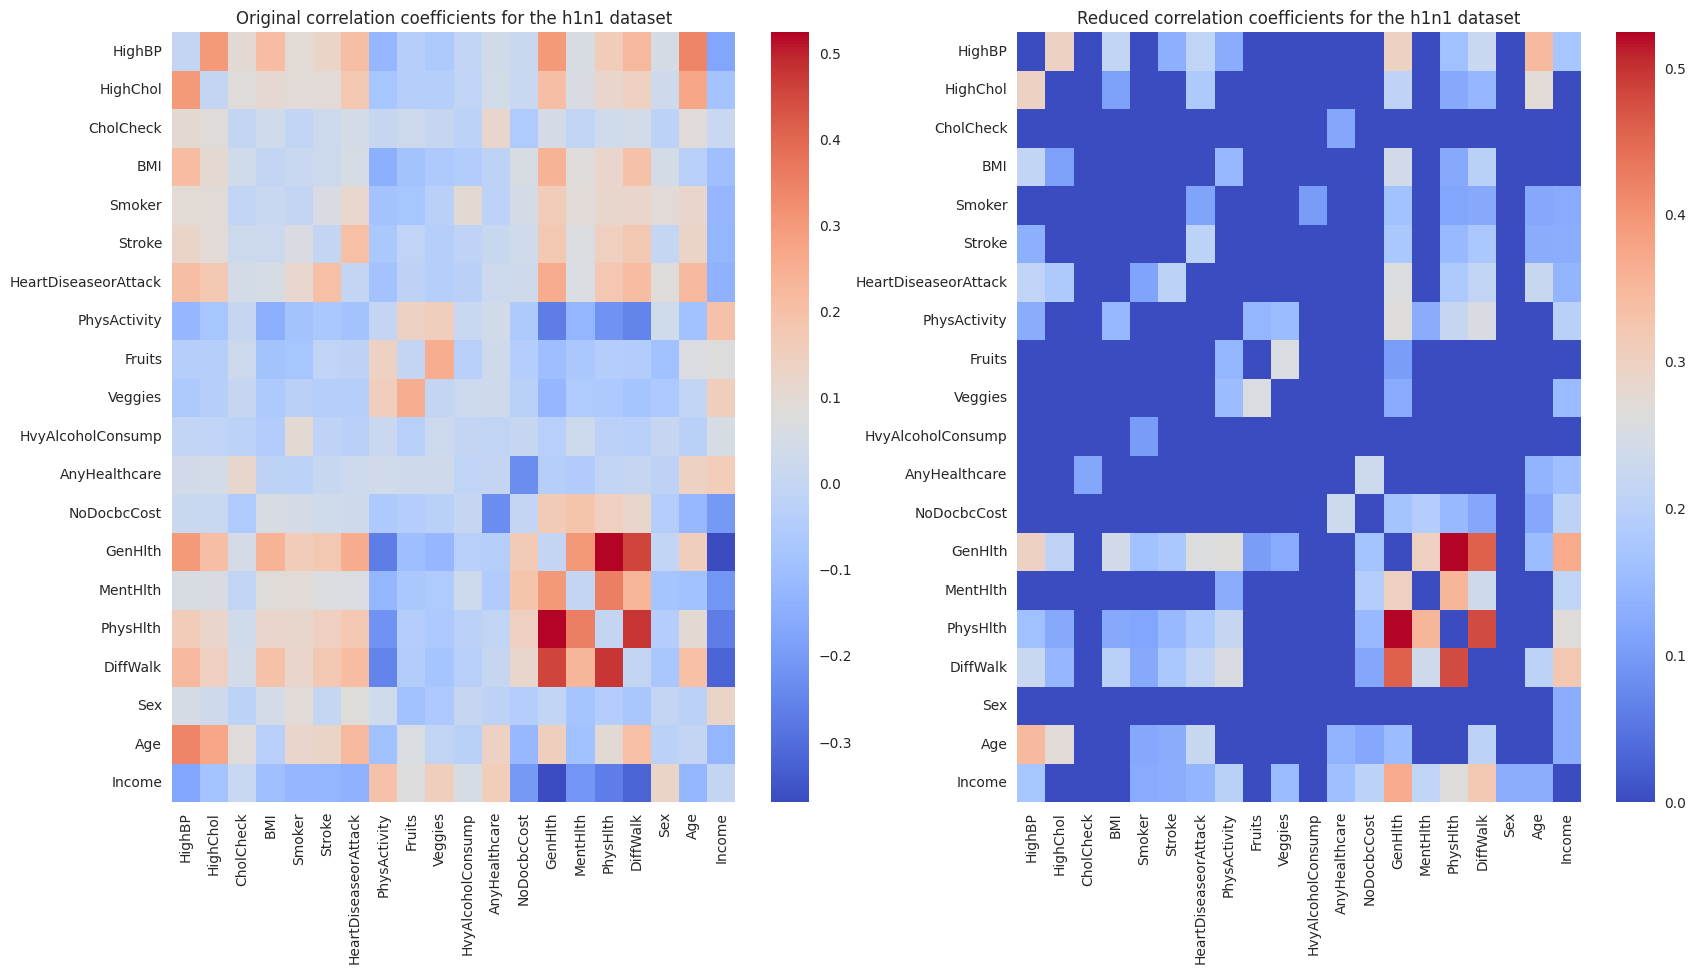

In [24]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W_vac_org, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the h1n1 dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new_vac_org, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the h1n1 dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()

In [6]:
from sklearn.covariance import GraphicalLasso, graphical_lasso

In [64]:
# explain the model
X_vac, y_vac = h1n1_data_reader('./data/process_data.csv')
# W_hd = matrix_generator(X_hd, method="stars_glasso")

W_vac = matrix_generator_lasso(X_vac, method="stars_glasso",
                            # B=80, subsample_frac=0.9, beta=0.10,              # more tolerant stability
                            alphas=None,                                      # we'll patch to extend grid
                            nonparanormal=True,                                # try False as an A/B if needed
                            # StARS: more precise stability estimates
                            B=200,                 # more subsamples
                            subsample_frac=0.95,   # larger subsamples
                            beta=0.03,             # stricter stability

                            # Solver: tighter & longer
                            max_iter=500,          # more CD iterations
                            )
W_vac, W_vac = stars_glasso_corr_generator_lasso(X_vac, return_probs=True)  # with stability probs
A_vac, W_new_vac = create_minimal_edge_graph(W_vac, reverse=True, version='v3')

# A_hd, W_new_hd = create_minimal_edge_graph(W_hd, reverse=True, version='v3')
G_vac = nx.Graph(A_vac)
shapley_value_vac = shapley.shapG(G_vac, m=3, f=classification_kpi, approximate_by_ratio=False)
fig, ax = shapGplot(shapley_value_vac, top_n=30, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 30 influential features', fontsize=16)
plt.show()

KeyboardInterrupt: 

In [8]:
plot_graph(W_new_vac, file_name=None)

NameError: name 'W_new_vac' is not defined

[mst_knn2] edges selected: 59


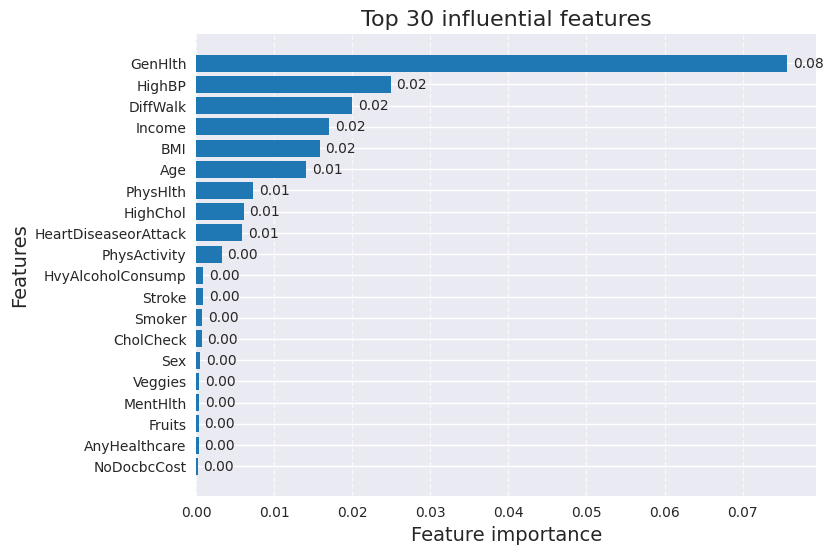

In [ ]:
# explain the model
X_vac_mst, y_vac_mst = heart_disease_data_reader('./data/diabetes_binary_health_indicators_BRFSS2015.csv')
W_vac_mst = matrix_generator_mst(X_vac_mst, pearsonr)
A_vac_mst, W_new_vac_mst = create_minimal_edge_graph_mst(W_vac_mst, version='mst', verbose=True)
G_vac_mst = nx.Graph(A_vac_mst)
shapley_value_vac_mst = shapley.shapG(
    G_vac_mst,
    m=5,
    f=classification_kpi,
    approximate_by_ratio=True
)
fig_mst, ax_mst = shapGplot(shapley_value_vac_mst, top_n=30, show_plot=False)
ax_mst.set_xlabel("Feature importance", fontsize=14)
ax_mst.set_ylabel("Features", fontsize=14)
ax_mst.spines['top'].set_visible(False)
ax_mst.spines['right'].set_visible(False)
ax_mst.set_title('Top 30 influential features', fontsize=16)
plt.show()

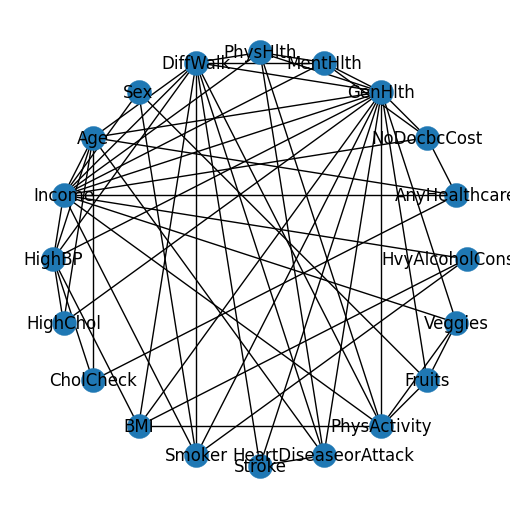

In [33]:
plot_graph(W_new_vac_mst, file_name=None)

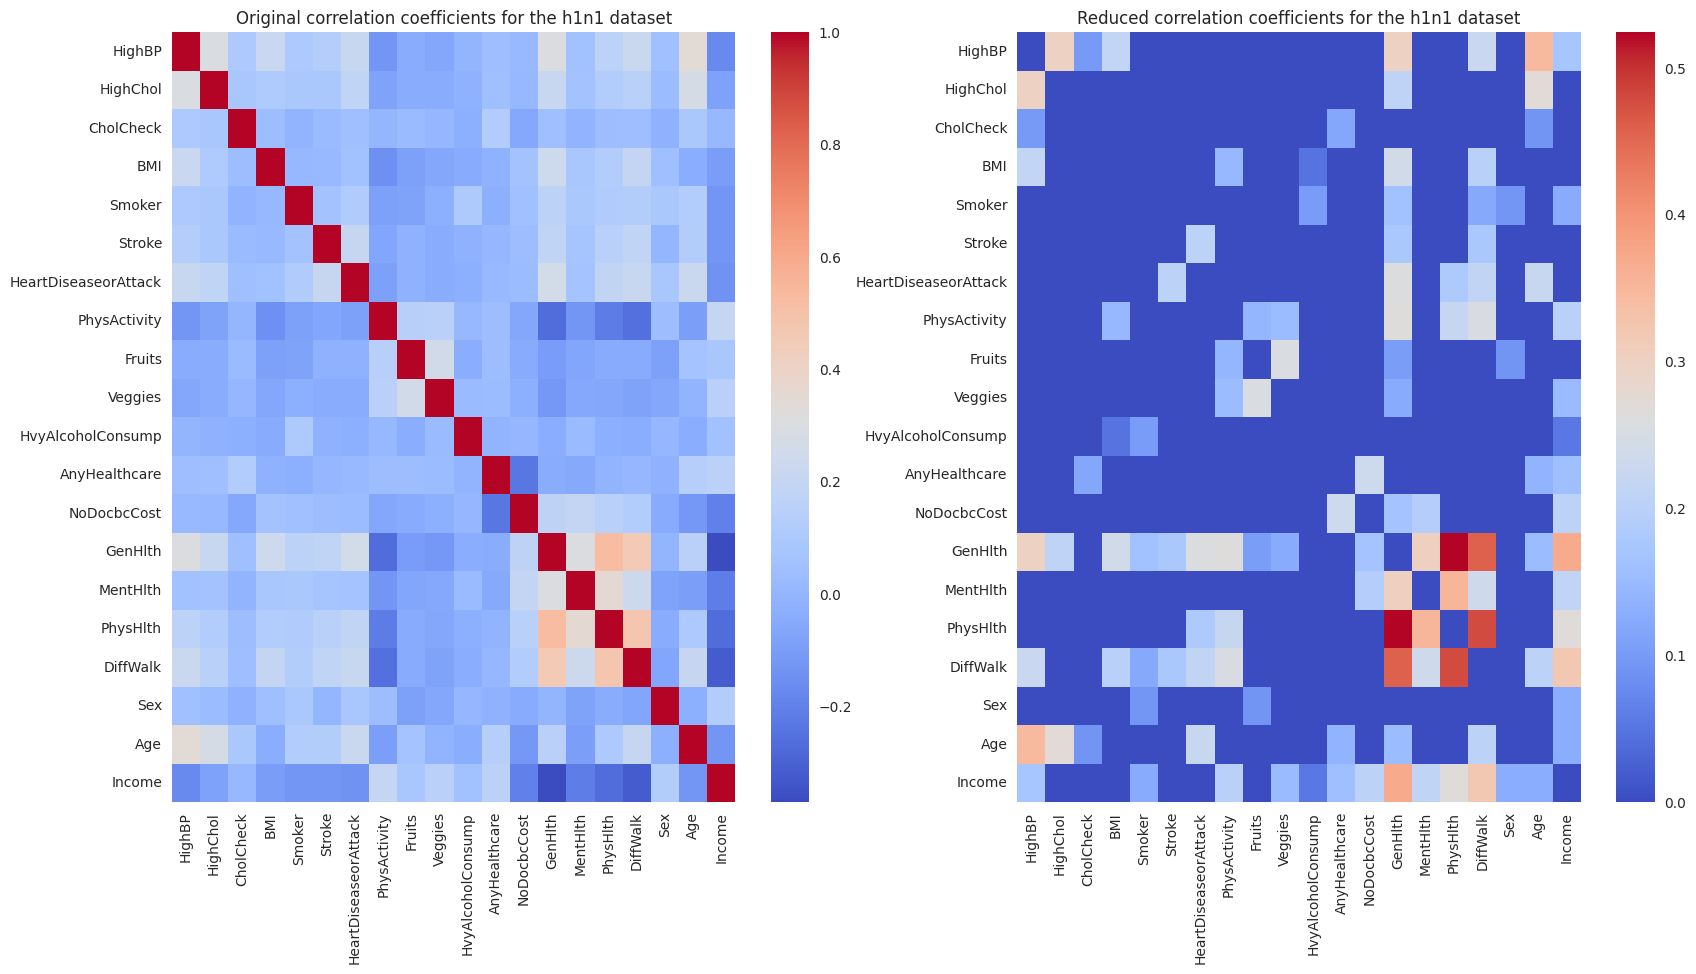

In [34]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W_vac_mst, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the h1n1 dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new_vac_mst, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the h1n1 dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()

In [18]:
import xgboost

import shap

# train XGBoost model
X_vac_shap, y_vac_shap = heart_disease_data_reader(filename='./data/diabetes_binary_health_indicators_BRFSS2015.csv')
model = lgb.LGBMRegressor(learning_rate=0.2, verbosity=-1).fit(X_vac_shap, y_vac_shap)
# compute SHAP values
explainer = shap.Explainer(model, X_vac_shap)
shap_values = explainer(X_vac_shap)


/home/khoim/.local/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
100%|===================| 253527/253680 [07:06<00:00]        

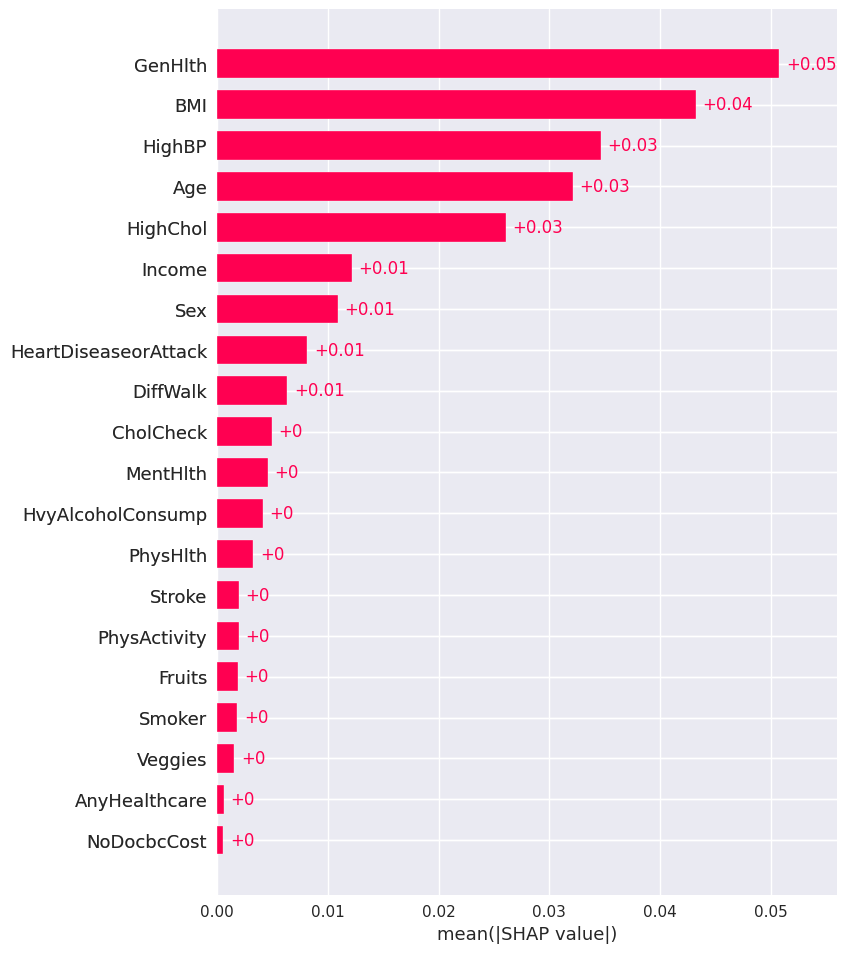

In [19]:
shap.plots.bar(shap_values, max_display=30)

In [100]:
# explain the model
X_vac_mst_graph, y_vac_mst_graph = h1n1_data_reader('./data/process_data.csv')
W_vac_mst_graph = matrix_generator_mst(X_vac_mst_graph, pearsonr)
A_vac_mst_graph, W_new_vac_mst_graph = create_minimal_edge_graph_mst_graph(
    W_vac_mst_graph,
    version='mst_dense',
    pct_tau=1,           # lower (e.g., 0.90) -> denser
    knn_k=8,                # raise to 10 if you still want more magnitude
    avg_degree_floor=2.0,   # try 3.4 if still small; 3.0 if too dense
    min_degree_floor=2,
    triangle_closing=True,
    triangle_budget_per_node=3,
    verbose=True
)
G_vac_mst_graph = nx.Graph(A_vac_mst_graph)
shapley_value_vac_mst_graph = shapley.shapG(
    G_vac_mst_graph,
    m=3,
    f=classification_kpi,
    depth=1,
    approximate_by_ratio=True,  # rescales sum(φ) to the full value
    scale=True
)
fig_mst, ax_mst = shapGplot(shapley_value_vac_mst_graph, top_n=30, show_plot=False)
ax_mst.set_xlabel("Feature importance", fontsize=14)
ax_mst.set_ylabel("Features", fontsize=14)
ax_mst.spines['top'].set_visible(False)
ax_mst.spines['right'].set_visible(False)
ax_mst.set_title('Top 30 influential features', fontsize=16)
plt.show()

[mst_dense] +global(≥τ=1.00)=1 edges=35 avg_deg=2.00
[mst_dense] +knn(k=8)=280 edges=315 avg_deg=18.00
[mst_dense] +min_deg=0, +avg_deg=0 edges=315 avg_deg=18.00
[mst_dense] +triangles=105 FINAL edges=420 avg_deg=24.00


KeyError: "None of [Index(['health_insurance', 'employment_occupation', 'behavioral_outside_home',\n       'child_under_6_months', 'opinion_h1n1_risk', 'behavioral_touch_face',\n       'employment_status', 'chronic_med_condition', 'education',\n       'household_children', 'h1n1_knowledge', 'census_msa', 'age_group',\n       'behavioral_avoidance', 'opinion_seas_vacc_effective',\n       'opinion_seas_risk', 'race', 'employment_industry', 'marital_status',\n       'rent_or_own', 'behavioral_face_mask', 'doctor_recc_seasonal',\n       'hhs_geo_region', 'h1n1_concern', 'sex', 'opinion_seas_sick_from_vacc',\n       'income_poverty', 'household_adults', 'doctor_recc_h1n1',\n       'behavioral_large_gatherings', 'behavioral_wash_hands',\n       'opinion_h1n1_vacc_effective', 'opinion_h1n1_sick_from_vacc',\n       'health_worker', 'behavioral_antiviral_meds'],\n      dtype='object')] are in the [columns]"

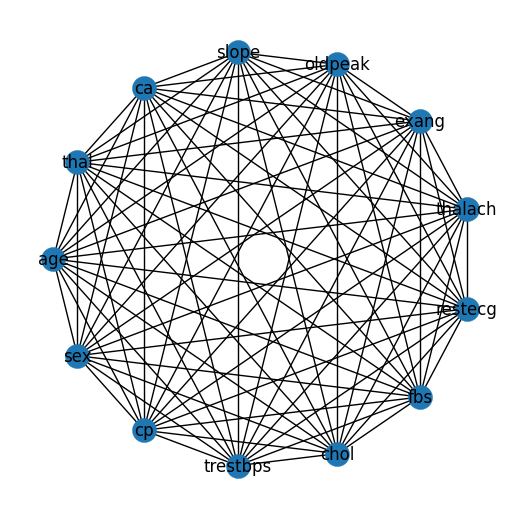

In [92]:
plot_graph(W_new_vac_mst_graph, file_name=None)

In [81]:
# explain the model
W2 = kl_mi_matrix(X, y)
A2, W2_new = create_minimal_edge_graph(W, reverse=True, version='v3')
G2 = nx.Graph(A2)
shapley_value2 = shapley.shapG(G2, m=3, f=classification_kpi, approximate_by_ratio=False)
fig, ax = shapGplot(shapley_value2, top_n=15, show_plot=False)
ax.set_xlabel("Feature importance", fontsize=14)
ax.set_ylabel("Features", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_title('Top 15 influential features', fontsize=16)
plt.show()

NameError: name 'X' is not defined

### Some useful code snippet for draw the figure

In [80]:
import seaborn as sns
import networkx as nx

# plot the networkx graph for W and W_new
def plot_graph(W, file_name=None):
    """_summary_

    Args:
        W (pd.DataFrame): weight matrix
    """
    G = nx.Graph(W)
    plt.figure(figsize=(5, 5))
    nx.draw_shell(G, with_labels=True)
    if file_name is not None:
        plt.savefig(file_name, format='eps', dpi=300)
    plt.show()

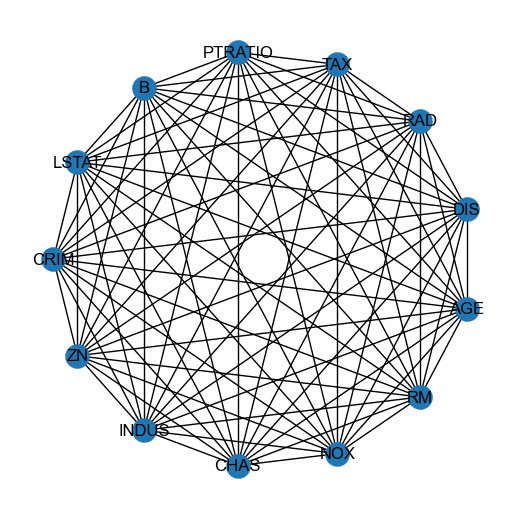

In [7]:
plot_graph(W, file_name=None)

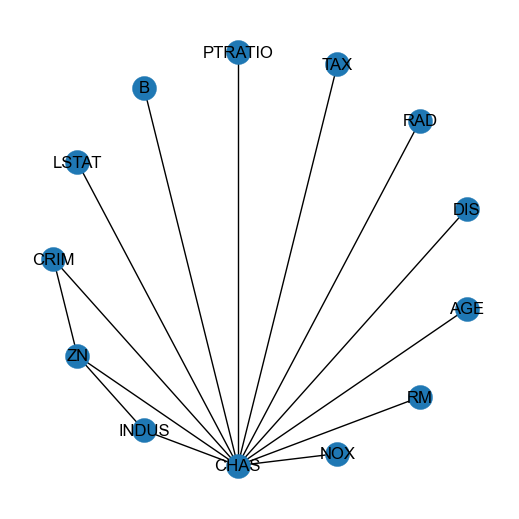

In [8]:
plot_graph(W_new, file_name=None)

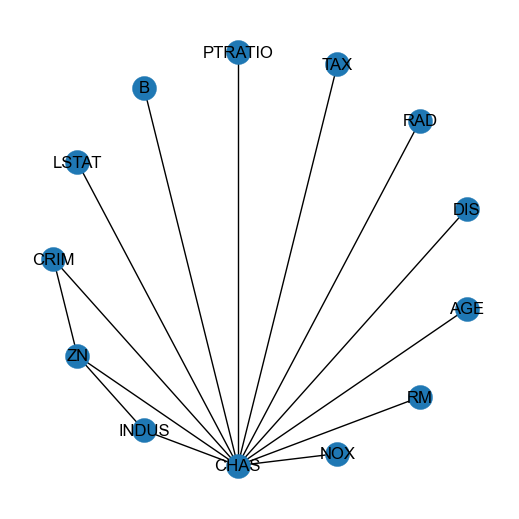

In [9]:
plot_graph(W2_new, file_name=None)

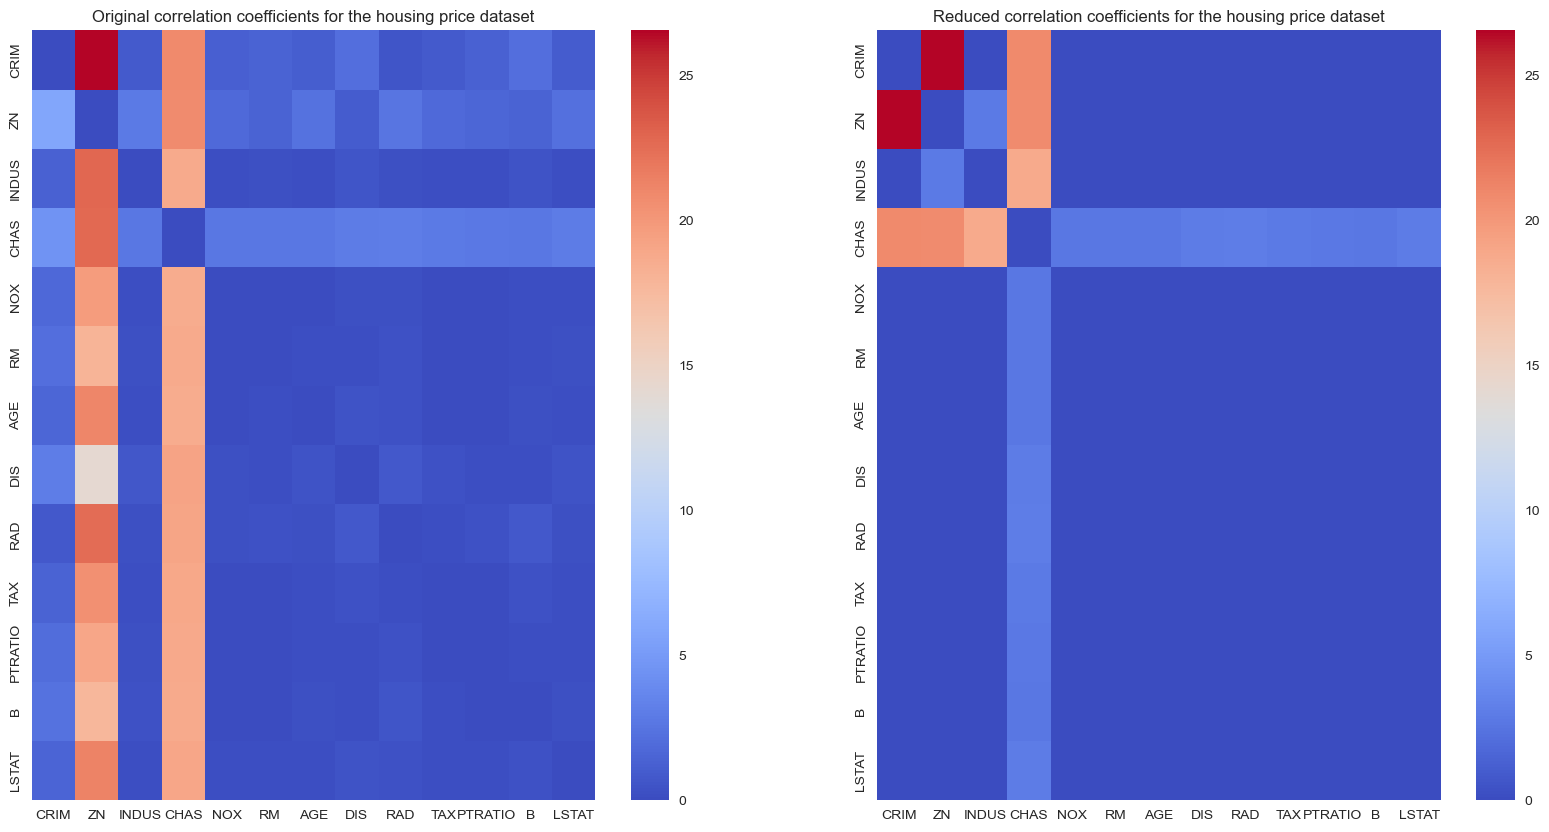

In [10]:
# create two heatmaps for W and W_new
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
sns.heatmap(W, annot=False, cmap='coolwarm', cbar=True)
plt.title('Original correlation coefficients for the housing price dataset')
plt.subplot(1, 2, 2)
sns.heatmap(W_new, annot=False, cmap='coolwarm', cbar=True)
plt.title('Reduced correlation coefficients for the housing price dataset')
# plt.savefig('housing-heatmap.eps', format='eps', dpi=300)

plt.show()